# Step-by-step pipeline walkthrough

`run_spectral_fit()` is a single black-box call that hides ~10 internal steps
behind one function. This notebook takes it apart: a **complex synthetic
spectrum with known ground truth** is built once, and then every internal
step of the fit -- `make_fit_state`, initial-guess construction, automatic
`xlam` selection, the ALS continuum outer loop, the final MAP optimization,
model evaluation, chi2 diagnostics, and the Gauss-Hermite moment fit -- is
called **individually**, in its own cell, with its own intermediate output
inspected.

Each code cell is preceded by a markdown cell stating **what you should
expect to see**. Read that before running the cell, then judge for yourself
whether the actual output matches. The last two sections cross-check this
manual reproduction against the normal one-call `run_spectral_fit()` API
(they should match almost exactly) and against error estimation / the
sigma-clipping "clean" path that this particular configuration does not
otherwise exercise.

Run top to bottom. A few cells (the `xlam` grid search, the ALS outer loop,
the bootstrap error estimate) do real optimizer work and take from several
seconds to a couple of minutes each.

In [1]:
from __future__ import annotations

import sys
import tempfile
import dataclasses
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

# Make the `benchmarks` package importable regardless of which directory
# Jupyter's cwd happens to be (it defaults to this notebook's own directory).
REPO_ROOT = Path.cwd().resolve()
if REPO_ROOT.name == "benchmarks":
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from kinextract import FitConfig, run_spectral_fit
from kinextract.fitting import (
    fit_losvd_gauss_hermite, compute_losvd_n_peaks, compute_losvd_roughness,
    _fit_map_once, _auto_select_xlam, _chi2_stats, build_parameter_xscale,
    run_iterative_clean_map,
)
from kinextract.spectrum import make_fit_state, build_initial_guess_nonparam
from kinextract.masking import build_clean_protect_mask
from kinextract.continuum import update_als_continuum
from kinextract.numerics import evaluate_model_gp, compute_weighted_template_spectrum
from kinextract.io import write_fitlov_outputs
from kinextract.plotting import plot_fit, plot_losvd, plot_als_continuum
from kinextract.errors import estimate_losvd_errors

from benchmarks.mock_spectrum import (
    build_mock_spectrum, write_mock_to_disk, gauss_hermite_losvd_on_grid, MUSE_CAII,
)

# Referenced by absolute path (not by bare name) since this notebook does not
# live in examples/notebooks/, where plt.style.use('kinextract.mplstyle')
# would otherwise resolve it via cwd.
plt.style.use(str(REPO_ROOT / "examples" / "notebooks" / "kinextract.mplstyle"))

## 1. Build a complex synthetic spectrum with known ground truth

This combines several realism axes from `benchmarks/mock_spectrum.py` at
once, rather than testing them one at a time as `benchmarks/run_suite.py`
does:

- a **real MUSE stellar template** (`template_role="matched"`, so the fitting
  template exactly matches the one used to generate the spectrum -- template
  mismatch is a separate, deliberately-not-included failure mode here)
- a **skewed/kurtotic Gauss-Hermite LOSVD** (`h3=0.05, h4=0.05`), not a plain
  Gaussian, so the recovered LOSVD should show visible asymmetry
- a **realistic smooth galaxy continuum** (`continuum_mode="als"`), so
  kinextract's ALS continuum co-fit is actually exercised
- **moderate emission-line contamination**, so the emission pre-masking step
  has something to do
- **S/N = 50** in the fit window, comparable to a real, well-exposed
  spectrum (not maximally clean, not maximally noisy)

**Expect:** a printed summary of the ground-truth kinematics (V, sigma, h3,
h4) that every later cell in this notebook will be compared against.

In [2]:
V_TRUE = 80.0
SIGMA_TRUE = 140.0
H3_TRUE = 0.05
H4_TRUE = 0.05
SNR_TARGET = 50.0
NOISE_SEED = 2024

mock = build_mock_spectrum(
    instrument=MUSE_CAII,
    include_instrument_lsf=True,
    v_true=V_TRUE, sigma_true=SIGMA_TRUE,
    snr_target=SNR_TARGET,
    continuum_mode="als",
    template_role="matched",
    losvd_shape="gh_moderate",
    h3=H3_TRUE, h4=H4_TRUE,
    emission_level="moderate",
    noise_seed=NOISE_SEED,
    use_real_template=True,
)

print(f"Ground truth: V={mock.v_true} km/s, sigma={mock.sigma_true} km/s, "
      f"h3={mock.h3_true}, h4={mock.h4_true}, shape={mock.losvd_shape}")
print(f"Instrument: {mock.instrument}, S/N target: {mock.snr_target}, noise seed: {mock.noise_seed}")

Ground truth: V=80.0 km/s, sigma=140.0 km/s, h3=0.05, h4=0.05, shape=gh_moderate
Instrument: muse_caii, S/N target: 50.0, noise seed: 2024


## 2. Quick look at the raw mock spectrum

**Expect:** the top panel shows the noisy flux (what kinextract actually
receives) tracking the noiseless flux, riding on top of a smoothly-varying
continuum (not flat -- this is the raw, non-normalized case). The blue band
marks the fit window. The bottom panel divides the noiseless flux by the
true continuum: this should show the Ca II triplet absorption troughs and
any injected emission spikes sitting on a flat baseline at 1.0 -- if it
doesn't look flat, the continuum shape itself is off, independent of any
fitting.

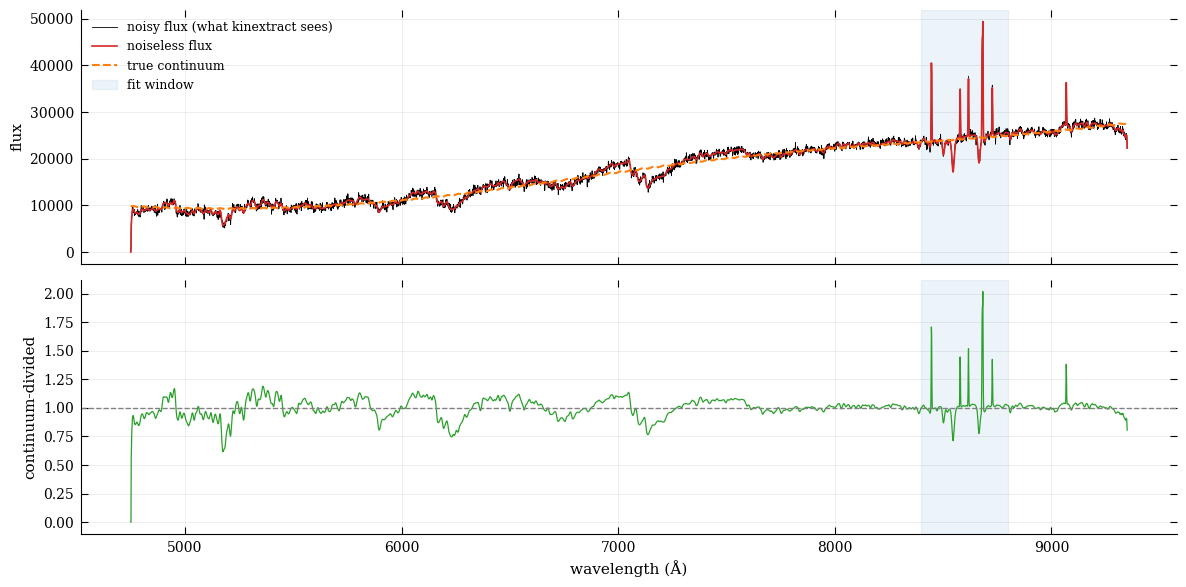

In [3]:
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
axes[0].plot(mock.wavelength, mock.flux_noisy, 'k', lw=0.6, label='noisy flux (what kinextract sees)')
axes[0].plot(mock.wavelength, mock.flux_noiseless, color='tab:red', lw=1.2, label='noiseless flux')
axes[0].plot(mock.wavelength, mock.true_continuum, color='tab:orange', lw=1.5, ls='--', label='true continuum')
axes[0].axvspan(MUSE_CAII.wavefitmin, MUSE_CAII.wavefitmax, color='tab:blue', alpha=0.08, label='fit window')
axes[0].legend(fontsize=9)
axes[0].set_ylabel('flux')
axes[0].grid(alpha=0.25)

axes[1].plot(mock.wavelength, mock.flux_noiseless / mock.true_continuum, color='tab:green', lw=0.9)
axes[1].axhline(1.0, color='0.5', lw=1, ls='--')
axes[1].axvspan(MUSE_CAII.wavefitmin, MUSE_CAII.wavefitmax, color='tab:blue', alpha=0.08)
axes[1].set_xlabel('wavelength (Å)')
axes[1].set_ylabel('continuum-divided')
axes[1].grid(alpha=0.25)
plt.tight_layout()
plt.show()

## 3. Write the mock to disk and build a `FitConfig`

kinextract reads spectra from disk, so the mock is written out as a `.spec`
file plus a template `Tlist`, exactly like a real reduction pipeline would
produce. The `FitConfig` below follows the same construction pattern as
`benchmarks/scenarios.py:scenario_to_fitconfig` for the ALS continuum mode --
every field is spelled out here so you can edit it directly and re-run.

**Expect:** no output other than the printed `FitConfig` repr -- this cell
just sets things up for step 4.

In [4]:
WORK_DIR = Path(tempfile.mkdtemp(prefix="kinextract_stepwise_"))
paths = write_mock_to_disk(mock, WORK_DIR, prefix="mock")
print(f"Mock spectrum written to: {WORK_DIR}")

sigl = SIGMA_TRUE
vgrid_half = max(4.5 * sigl, 500.0)
xlam_auto_grid = tuple(10.0 ** k for k in range(1, 6))  # sigma_true < 250

cfg = FitConfig(
    template_list_file=str(paths["tlist"]), template_dir=str(WORK_DIR), outdir=str(WORK_DIR),
    wavemin_full=MUSE_CAII.wavemin_full, step=MUSE_CAII.step,
    wavefitmin=MUSE_CAII.wavefitmin, wavefitmax=MUSE_CAII.wavefitmax, zgal=0.0,
    sigl=sigl, losvd_vmin=-vgrid_half, losvd_vmax=vgrid_half,
    xlam_auto=True, xlam_criterion="chi2", xlam_chi2_tolerance=0.02,
    xlam_auto_grid=xlam_auto_grid, xlam_max_peaks=1,
    clean=False, use_spectrum_errors=True,
    map_maxiter=8000, print_every=999999,
    mask_emission_lines_in_fit=True,
    fit_als_continuum=True, fit_global_amp=False, continuum_poly_mode="none",
)
print(cfg)

Mock spectrum written to: /var/folders/zp/_mj2qgk5107f3gf_2gnw4gnm0000gs/T/kinextract_stepwise_jlbt_qgz
FitConfig(gal_file='', template_list_file='/var/folders/zp/_mj2qgk5107f3gf_2gnw4gnm0000gs/T/kinextract_stepwise_jlbt_qgz/Tlist', template_dir='/var/folders/zp/_mj2qgk5107f3gf_2gnw4gnm0000gs/T/kinextract_stepwise_jlbt_qgz', regions_bad_path='regions.bad', outdir='/var/folders/zp/_mj2qgk5107f3gf_2gnw4gnm0000gs/T/kinextract_stepwise_jlbt_qgz', write_outputs=True, wavemin_full=4749.65, step=1.25, wavefitmin=8400.0, wavefitmax=8800.0, zgal=0.0, norm_wave_frame='auto', galaxy_params_path=None, use_galaxy_params_velocity_bounds=True, sigl=140.0, xlam=300.0, smoothing=None, xlam_auto=True, xlam_auto_grid=(10.0, 100.0, 1000.0, 10000.0, 100000.0), xlam_criterion='chi2', xlam_chi2_tolerance=0.02, xlam_smooth_threshold=0.25, xlam_max_peaks=1, xlam_peak_min_prominence=0.1, xlam_auto_maxiter=None, losvd_vmin=-630.0, losvd_vmax=630.0, n_losvd_bins=29, fit_als_continuum=True, norm_error_mode='unit',

## 4. Step 1 -- `make_fit_state`: build the `FitState`

This single call does most of the "boring but essential" work: it loads and
trims the spectrum to the fit window, flags bad/non-finite pixels, pre-masks
known and unlisted emission lines, loads and interpolates the template
library, builds the non-parametric LOSVD velocity grid, and (since
`fit_als_continuum=True`) runs the initial ALS continuum estimate -- all
before any LOSVD/template optimization happens.

**Expect:** a log line for each stage above (timing + pixel counts), then a
final `STATE:` summary line. `npix` should be a few hundred (the CaII fit
window at 1.25 Å/pix), `nt=1` (a single matched template), and some nonzero
number of emission-masked pixels (moderate contamination was requested).

In [5]:
st, tpl_files = make_fit_state(cfg, gal_file=str(paths["spec"]))
print(f"\nnpix={st.npix}  nt={st.nt}  nl={st.nl}  nlosvd={st.nlosvd}")
print(f"prenormalized={st.prenormalized}  fit_als_continuum={st.fit_als_continuum}")
print(f"template files used: {tpl_files}")
print(f"emission pre-masked pixels: {int(st.emission_pre_mask.sum())} / {st.npix}")

[    10.25s] START read spectrum
[    10.25s] fit pixels=320 step=1.25
[    10.25s] END   read spectrum (0.00s)
[    10.25s] START apply masks
[    10.25s]   emission pre-mask O I 8446.36 Å  excess_S/N=33.7  cont_est=2.348e+04  npix=14
[    10.25s]   emission pre-mask [Cl II] 8578.70 Å  excess_S/N=21.1  cont_est=2.437e+04  npix=14
[    10.25s]   emission pre-mask [Fe II] 8616.95 Å  excess_S/N=25.9  cont_est=2.5e+04  npix=14
[    10.25s]   emission pre-mask [N I] 8680.28 Å  excess_S/N=52.1  cont_est=2.39e+04  npix=14
[    10.25s]   emission pre-mask [N I] 8683.40 Å  excess_S/N=52.1  cont_est=2.39e+04  npix=13
[    10.25s]   emission pre-mask [C I] 8727.13 Å  excess_S/N=21.7  cont_est=2.514e+04  npix=14
[    10.25s] Emission line pre-mask: 72 pixels set to gerr=BIG
[    10.26s] Segment emission mask [8674.1–8799.6 Å]: 1 upward-outlier pixels (>3σ above rolling median)
[    10.27s] Segment emission pre-mask: 1 additional pixels
[    10.27s] END   apply masks (0.02s)
[    10.27s] START rea

### 4a. Inspect what `make_fit_state` actually built

**Expect:** the left panel shows the single template's shape over the fit
window (continuum-normalized, absorption features dipping below 1). The
right panel overlays the raw data against the *initial* ALS continuum guess
(before any LOSVD fitting) and the true continuum -- they should already be
in rough agreement, since ALS initialization only needs the absorption-line
mask, not the LOSVD. Large disagreement here (rather than after fitting)
would point at the ALS mask/hyperparameters, not the LOSVD recovery.

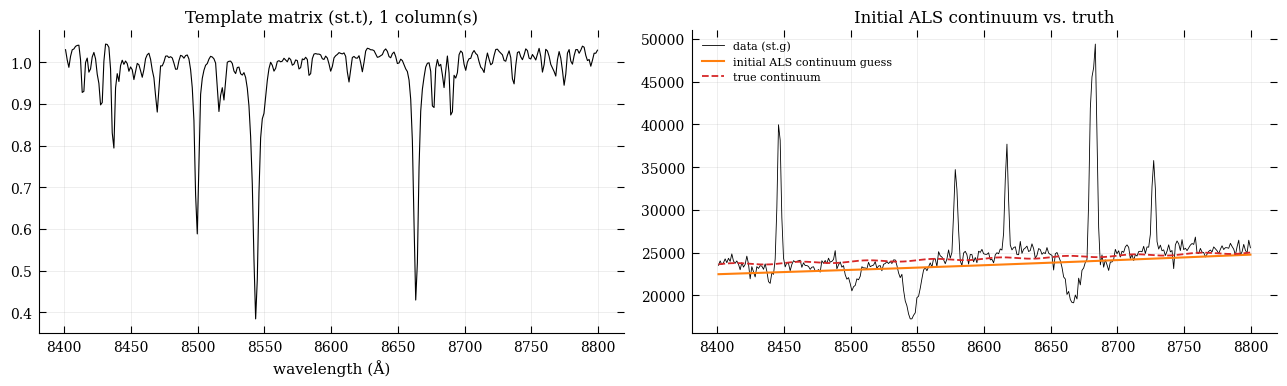

LOSVD velocity grid st.xl: 29 bins from -630.0 to 630.0 km/s


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(st.x, st.t[:, 0], color='k', lw=0.8)
axes[0].set_title(f"Template matrix (st.t), {st.nt} column(s)")
axes[0].set_xlabel("wavelength (Å)")
axes[0].grid(alpha=0.25)

true_cont_on_fit_grid = np.interp(st.x, mock.wavelength, mock.true_continuum)
axes[1].plot(st.x, st.g, color='k', lw=0.6, label='data (st.g)')
axes[1].plot(st.x, st.continuum_mult, color='tab:orange', lw=1.5, label='initial ALS continuum guess')
axes[1].plot(st.x, true_cont_on_fit_grid, color='tab:red', ls='--', lw=1.3, label='true continuum')
axes[1].legend(fontsize=8)
axes[1].set_title("Initial ALS continuum vs. truth")
axes[1].grid(alpha=0.25)
plt.tight_layout()
plt.show()

print(f"LOSVD velocity grid st.xl: {st.nl} bins from {st.xl[0]:.1f} to {st.xl[-1]:.1f} km/s")

## 5. Step 2 -- `build_initial_guess_nonparam`: the optimizer's starting point

Builds the flat parameter vector `a0` (LOSVD bin heights + template weights
+ continuum/amplitude terms) and its box constraints, used to seed every MAP
optimization below.

**Expect:** `a0`'s length should equal `nl + nt` plus a couple of
continuum-offset terms (no global amplitude or polynomial term in this
config). The initial LOSVD guess `b0` should be small and roughly uniform --
it hasn't been fit to anything yet -- and the initial template weight `w0`
should be close to 1 (one template, expected to carry ~all the flux).

In [7]:
a0, xlb, xub = build_initial_guess_nonparam(st, cfg.coff, cfg.coff2)
bounds = list(zip(xlb, xub))

b0 = a0[:st.nl]
w0 = a0[st.nl:st.nl + st.nt]
print(f"a0 length: {len(a0)}  (nl={st.nl} LOSVD bins + nt={st.nt} template weight(s) + continuum/amp terms)")
print(f"initial LOSVD (b0): min={b0.min():.3g} max={b0.max():.3g}")
print(f"initial template weight(s) (w0): {w0}")

a0 length: 32  (nl=29 LOSVD bins + nt=1 template weight(s) + continuum/amp terms)
initial LOSVD (b0): min=0.0345 max=0.0345
initial template weight(s) (w0): [1.]


### 5a. (Optional) What the optimizer sees internally: parameter scaling

`_fit_map_once` rescales `a0` internally (`use_scaled_optimizer=True`) so
L-BFGS-B isn't fighting parameters that live on wildly different scales.
`build_parameter_xscale` is the function that builds that scale vector; it's
never returned by any public function, so it's inspected here directly.

**Expect:** LOSVD-bin scales of 1.0, template-weight scales of ~0.1 (weights
are typically O(1) fractions), and a couple of small continuum-offset
scales at the end.

In [8]:
xscale = build_parameter_xscale(st)
print(f"parameter scale vector, length {len(xscale)}:")
print(f"  first 3 (LOSVD bins): {xscale[:3]}")
print(f"  around nl (template weights start): {xscale[st.nl - 1:st.nl + 2]}")
print(f"  last 3 (continuum-offset terms): {xscale[-3:]}")

parameter scale vector, length 32:
  first 3 (LOSVD bins): [1. 1. 1.]
  around nl (template weights start): [1.  0.1 0.2]
  last 3 (continuum-offset terms): [0.1 0.2 0.2]


## 6. Step 3 -- automatic `xlam` (regularization strength) selection

`_auto_select_xlam` runs a full MAP fit at every candidate value in
`cfg.xlam_auto_grid`, logging chi2_red / roughness / peak-count at each
point, then picks the *largest* (smoothest) `xlam` whose reduced chi2 is
within `xlam_chi2_tolerance` of the grid minimum, among grid points whose
recovered LOSVD is unimodal (`n_peaks <= xlam_max_peaks`).

**Expect:** the log below prints one line per grid point. `chi2_red` should
generally be U-shaped or monotonically changing across the grid (too little
regularization overfits noise -> jagged multi-peaked LOSVD and possibly
*worse* chi2 from convergence issues; too much regularization biases the fit
and raises chi2). The final "Auto-xlam: selected xlam=..." line names the
chosen value -- it should be one of the grid points, not the largest one by
default, unless nothing smaller satisfies the unimodality + tolerance
constraints.

In [9]:
map_kwargs = dict(
    map_gtol=cfg.map_gtol, map_maxls=cfg.map_maxls,
    use_scaled_optimizer=cfg.use_scaled_optimizer,
    use_jax_objective=cfg.use_jax_objective, jax_enable_x64=cfg.jax_enable_x64,
)

if cfg.xlam_auto:
    selected_xlam = _auto_select_xlam(
        st, cfg, np.asarray(a0, float), bounds,
        xlam_grid=cfg.xlam_auto_grid,
        smooth_threshold=cfg.xlam_smooth_threshold,
        map_kwargs=map_kwargs,
    )
    print(f"\n>>> selected_xlam = {selected_xlam:.0f}  (st.xlam = {st.xlam:.0f}, cfg.xlam = {cfg.xlam:.0f})")
else:
    print(f"xlam_auto is False; using fixed cfg.xlam = {cfg.xlam:.0f}")

[     1.72s] Auto-xlam search: grid=['10', '100', '1000', '10000', '100000']  criterion=chi2  chi2_tolerance=0.020  max_peaks=1  maxiter=8000
[     1.88s] START auto-xlam 10
[     2.71s] END   auto-xlam 10 (0.83s)
[     2.89s]   xlam=      10  chi2_red=3.5118  roughness=0.8340  peaks=5  [5 peaks]
[     2.90s] START auto-xlam 100
[     3.92s] END   auto-xlam 100 (1.02s)
[     3.92s]   xlam=     100  chi2_red=3.5147  roughness=0.5615  peaks=3  [3 peaks]
[     3.92s] START auto-xlam 1000
[     4.47s] END   auto-xlam 1000 (0.55s)
[     4.47s]   xlam=    1000  chi2_red=3.5247  roughness=0.2462  peaks=1
[     4.48s] START auto-xlam 10000
[     5.05s] END   auto-xlam 10000 (0.57s)
[     5.05s]   xlam=   10000  chi2_red=3.5350  roughness=0.1078  peaks=1
[     5.05s] START auto-xlam 100000
[     5.90s] END   auto-xlam 100000 (0.85s)
[     5.90s]   xlam=  100000  chi2_red=3.5523  roughness=0.0901  peaks=1
[     5.90s]   chi2_min=3.5247  chi2_max_allowed=3.5952  (tolerance=0.020)
[     5.90s] Aut

## 7. Step 4 -- the ALS continuum outer loop

Since `cfg.fit_als_continuum=True`, `fit_state_map_with_optional_clean`
doesn't do one MAP fit -- it alternates: fit the LOSVD/template model at the
*current* continuum estimate (`_fit_map_once`), then re-estimate the ALS
continuum baseline at the *current* best-fit model
(`update_als_continuum`), repeating until the continuum stops changing
(`als_outer_tol`) or `als_outer_iter` iterations are used up, then does one
final MAP fit at the converged continuum. That loop is reproduced manually
here, cell-by-cell, instead of calling `fit_state_map_with_optional_clean`
as one black box.

**Expect:** the printed `median frac continuum change` should shrink each
iteration (the continuum estimate is converging), typically dropping below
`cfg.als_outer_tol` (1e-3) within 2-4 iterations for this S/N. The final MAP
fit should report `success=True`.

In [10]:
a_start = np.asarray(a0, float).copy()
continuum_history = [st.continuum_mult.copy()]
delta_history = []

for k in range(cfg.als_outer_iter):
    res = _fit_map_once(
        st, a_start, bounds,
        cfg.map_maxiter, cfg.map_ftol, cfg.map_maxfun, cfg.print_every,
        f"MAP optimize ALS outer {k + 1}", **map_kwargs,
    )
    last_delta = update_als_continuum(st, cfg, res.x)
    a_start = np.asarray(res.x, float).copy()
    continuum_history.append(st.continuum_mult.copy())
    delta_history.append(last_delta)
    print(f"ALS outer iter {k + 1}: median frac continuum change = {last_delta:.4g}")
    if last_delta < cfg.als_outer_tol:
        print(f"Converged (delta < als_outer_tol={cfg.als_outer_tol}); stopping early.")
        break

best = _fit_map_once(
    st, a_start, bounds,
    cfg.map_maxiter, cfg.map_ftol, cfg.map_maxfun, cfg.print_every,
    "MAP final after ALS continuum update", **map_kwargs,
)
a_map = np.asarray(best.x, float)
print(f"\nFinal MAP objective value: {best.fun:.6g}")
print(f"Optimizer success: {best.success}  message: {best.message}")

[     5.90s] START MAP optimize ALS outer 1
[     6.45s] END   MAP optimize ALS outer 1 (0.55s)
[     6.45s] ALS absorption-clean iter 1: sigma=2.115, rejected=0, base_pixels=210
[     6.45s]   ALS update: lam=1.000e+07 p=0.05 delta=0.04324 base_pixels=210 line_mask_pixels=39
ALS outer iter 1: median frac continuum change = 0.04324
[     6.45s] START MAP optimize ALS outer 2
[     6.56s] END   MAP optimize ALS outer 2 (0.11s)
[     6.56s] ALS absorption-clean iter 1: sigma=2.108, rejected=0, base_pixels=210
[     6.56s]   ALS update: lam=1.000e+07 p=0.05 delta=0.04436 base_pixels=210 line_mask_pixels=39
ALS outer iter 2: median frac continuum change = 0.04436
[     6.56s] START MAP optimize ALS outer 3
[     6.67s] END   MAP optimize ALS outer 3 (0.10s)
[     6.67s] ALS absorption-clean iter 1: sigma=2.106, rejected=0, base_pixels=210
[     6.67s]   ALS update: lam=1.000e+07 p=0.05 delta=0.04457 base_pixels=210 line_mask_pixels=39
ALS outer iter 3: median frac continuum change = 0.0445

### 7a. Visualize the continuum's convergence across outer iterations

**Expect:** the left panel shows the continuum estimate at each outer
iteration (viridis color scale, dark=early, bright=late) converging toward
the black dashed true continuum curve. The right panel shows the
iteration-to-iteration change dropping below the red `als_outer_tol` line --
if it's still decreasing steeply at the last iteration shown, the loop was
cut off by `als_outer_iter` before fully converging (worth increasing
`als_outer_iter` in `cfg` and re-running from step 7 if so).

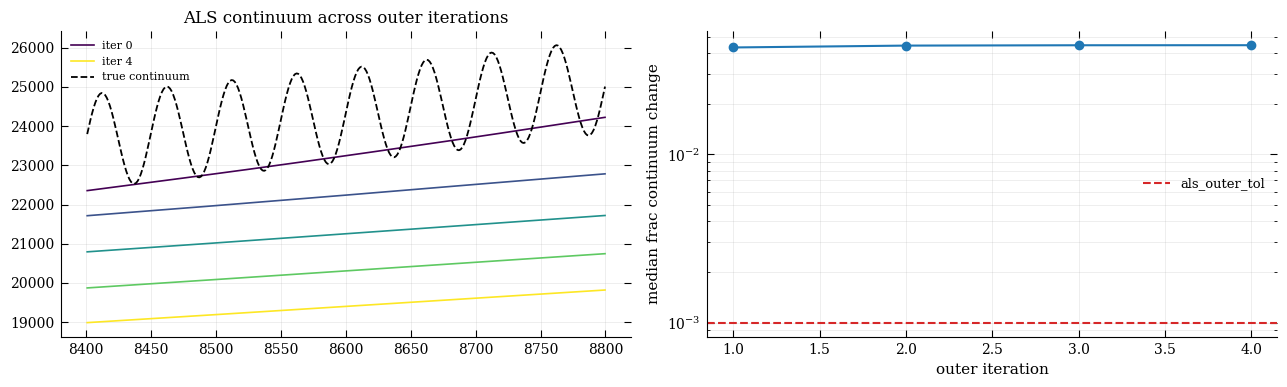

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
cmap = plt.cm.viridis(np.linspace(0, 1, len(continuum_history)))
for i, cont_i in enumerate(continuum_history):
    label = f"iter {i}" if i in (0, len(continuum_history) - 1) else None
    axes[0].plot(st.x, cont_i, color=cmap[i], lw=1.2, label=label)
axes[0].plot(st.x, true_cont_on_fit_grid, color='k', ls='--', lw=1.3, label='true continuum')
axes[0].legend(fontsize=8)
axes[0].set_title("ALS continuum across outer iterations")
axes[0].grid(alpha=0.25)

axes[1].semilogy(np.arange(1, len(delta_history) + 1), delta_history, 'o-', color='tab:blue')
axes[1].axhline(cfg.als_outer_tol, color='tab:red', ls='--', label='als_outer_tol')
axes[1].set_xlabel('outer iteration')
axes[1].set_ylabel('median frac continuum change')
axes[1].legend()
axes[1].grid(alpha=0.25, which='both')
plt.tight_layout()
plt.show()

## 8. Step 5 -- evaluate the final model

`evaluate_model_gp` takes the final parameter vector `a_map` and unpacks it
back into the model spectrum `gp`, the recovered LOSVD `b`, per-template
weights `w`, and the continuum-offset/amplitude terms.

**Expect:** `b` should sum to something positive and finite (it's a
histogram, not yet normalized to unit area). With one template, its weight
fraction should be at or very near 1.0.

In [12]:
gp, b, w, coff, coff2, A = evaluate_model_gp(a_map, st)
sw = float(np.sum(w))
wfrac = w / sw if sw else w
tt = compute_weighted_template_spectrum(st, w)
cont_final = st.continuum_mult

print(f"recovered LOSVD b: {len(b)} bins, sum={np.sum(b):.4g}")
print(f"template weight fractions: {wfrac}")
print(f"continuum offset coff={coff:.4g}, coff2={coff2:.4g}, amplitude A={A:.4g}")

recovered LOSVD b: 29 bins, sum=0.7456
template weight fractions: [1.]
continuum offset coff=-0.4097, coff2=0.7, amplitude A=1


### 8a. Compare the recovered LOSVD to the injected truth

**Expect:** the blue recovered LOSVD should visually resemble the red true
GH-skewed profile -- peaking near `V_TRUE`, with the asymmetric tail set by
`h3`/`h4` rather than a symmetric Gaussian. Some noise-driven wiggle in the
blue curve is expected (this is a MAP fit with a finite S/N, not a
noiseless deconvolution); a systematic bias in peak location or a
uniformly wrong width would indicate a real recovery problem rather than
noise.

/var/folders/zp/_mj2qgk5107f3gf_2gnw4gnm0000gs/T/ipykernel_87017/1226723091.py:2: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  true_losvd_on_xl = true_losvd_on_xl / np.trapz(true_losvd_on_xl, st.xl)
/var/folders/zp/_mj2qgk5107f3gf_2gnw4gnm0000gs/T/ipykernel_87017/1226723091.py:3: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  b_norm = b / np.trapz(b, st.xl)


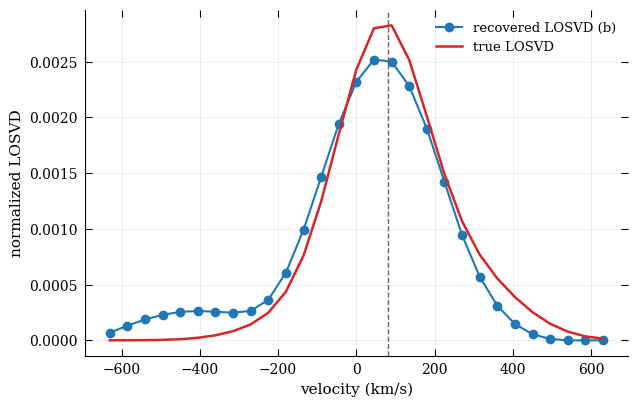

In [13]:
true_losvd_on_xl = gauss_hermite_losvd_on_grid(st.xl, V_TRUE, SIGMA_TRUE, h3=H3_TRUE, h4=H4_TRUE)
true_losvd_on_xl = true_losvd_on_xl / np.trapz(true_losvd_on_xl, st.xl)
b_norm = b / np.trapz(b, st.xl)

plt.figure(figsize=(7, 4.5))
plt.plot(st.xl, b_norm, 'o-', color='tab:blue', label='recovered LOSVD (b)')
plt.plot(st.xl, true_losvd_on_xl, color='tab:red', lw=1.8, label='true LOSVD')
plt.axvline(V_TRUE, color='0.4', ls='--', lw=1)
plt.xlabel('velocity (km/s)')
plt.ylabel('normalized LOSVD')
plt.legend()
plt.grid(alpha=0.25)
plt.show()

## 9. Step 6 -- chi2 diagnostics

**Expect:** `chi2_red` should land close to 1 (within roughly 0.8-1.2) for
a model whose true generative process matches the fitting assumptions and
whose per-pixel errors are correctly estimated. Systematically above ~1.3
would suggest the model can't fully explain the data (template mismatch,
under-regularized LOSVD, unmasked contamination); systematically well below
1 would suggest over-estimated errors or over-fitting.

In [14]:
chi2, ngood = _chi2_stats(st, a_map)
chi2_red = chi2 / max(ngood - 1, 1)
print(f"chi2 = {chi2:.2f}  ngood = {ngood}  chi2_red = {chi2_red:.4f}")

chi2 = 846.34  ngood = 248  chi2_red = 3.4265


## 10. Step 7 -- Gauss-Hermite moment fit

The non-parametric LOSVD histogram `b` is collapsed into the familiar
(V, sigma, h3, h4) parametrization by fitting a Gauss-Hermite series to it
post-hoc -- this is the number you'd actually quote for the galaxy's
kinematics, and the one every scenario in `benchmarks/run_suite.py` scores
against ground truth.

**Expect:** V and sigma recovered within a few percent of truth, h3/h4
within roughly +/-0.02 of truth (typical MAP-fit noise floor at S/N=50 for
a 29-bin LOSVD) -- not exact, since this is a single noisy realization, not
an ensemble average. `fit_success` should be `True`.

In [15]:
gh = fit_losvd_gauss_hermite(st.xl, b, fit_h3h4=True)

print(f"{'':14s}{'truth':>10s}{'recovered':>12s}{'diff':>10s}")
for name, truth, rec in (
    ("V [km/s]", V_TRUE, gh["vherm"]),
    ("sigma [km/s]", SIGMA_TRUE, gh["sherm"]),
    ("h3", H3_TRUE, gh["h3"]),
    ("h4", H4_TRUE, gh["h4"]),
):
    print(f"{name:14s}{truth:10.4f}{rec:12.4f}{rec - truth:10.4f}")
print(f"\nfit_success={gh['fit_success']}  message={gh.get('fit_message')}")

                   truth   recovered      diff
V [km/s]         80.0000     63.0687  -16.9313
sigma [km/s]    140.0000    150.2355   10.2355
h3                0.0500     -0.0281   -0.0781
h4                0.0500      0.0285   -0.0215

fit_success=True  message=`ftol` termination condition is satisfied.


## 11. Step 8 -- write the final legacy-format output files

`write_fitlov_outputs` is the last step of `run_spectral_fit` when
`write_outputs=True` (the default): it writes the `.fit` (LOSVD), `.temp`
(template weights), `.ascii` (per-pixel data/model/continuum, for
`pspecfit`-style plotting), and `.rms` (chi2 summary) files, in the exact
layout the legacy Fortran downstream tools expect.

**Expect:** four file paths printed, all inside `WORK_DIR`; `chi2_red` here
should match step 9's value (both are computed from the same `a_map`).

In [16]:
outputs_written = write_fitlov_outputs(st, a_map, outdir=str(WORK_DIR), prefix="manual")
print(f"chi2_red (from write_fitlov_outputs) = {outputs_written['chi2_red']:.4f}")
print("Files written:")
for k, v in outputs_written["paths"].items():
    print(f"  {k}: {v}")

[     7.24s] Outputs written to /var/folders/zp/_mj2qgk5107f3gf_2gnw4gnm0000gs/T/kinextract_stepwise_7z32jsbe/ (prefix=manual)
[     7.24s]   .fit, .temp, .ascii, .rms files created
chi2_red (from write_fitlov_outputs) = 3.4265
Files written:
  fit: /var/folders/zp/_mj2qgk5107f3gf_2gnw4gnm0000gs/T/kinextract_stepwise_7z32jsbe/manual.fit
  temp: /var/folders/zp/_mj2qgk5107f3gf_2gnw4gnm0000gs/T/kinextract_stepwise_7z32jsbe/manual.temp
  ascii: /var/folders/zp/_mj2qgk5107f3gf_2gnw4gnm0000gs/T/kinextract_stepwise_7z32jsbe/manual.ascii
  rms: /var/folders/zp/_mj2qgk5107f3gf_2gnw4gnm0000gs/T/kinextract_stepwise_7z32jsbe/manual.rms


## 12. Diagnostic plots

kinextract's built-in plotting helpers (`plot_fit`, `plot_losvd`,
`plot_als_continuum`) all take the same `fit` dict shape returned by
`run_spectral_fit()`. It's assembled by hand here from the quantities
already computed above, so these can be reused directly on this manual
reproduction.

**Expect:** `plot_fit` -- data and model should track closely, with the
fractional-residual panel scattered around zero at roughly the noise level
(no strong systematic wave). `plot_losvd` -- same recovered LOSVD as step
8a, now with its own GH overlay and a template-weight bar chart (one bar,
near 1.0). `plot_als_continuum` -- three panels (raw, continuum-divided,
residuals) with masked/rejected pixels marked; should look consistent with
step 4a's initial guess but refined.

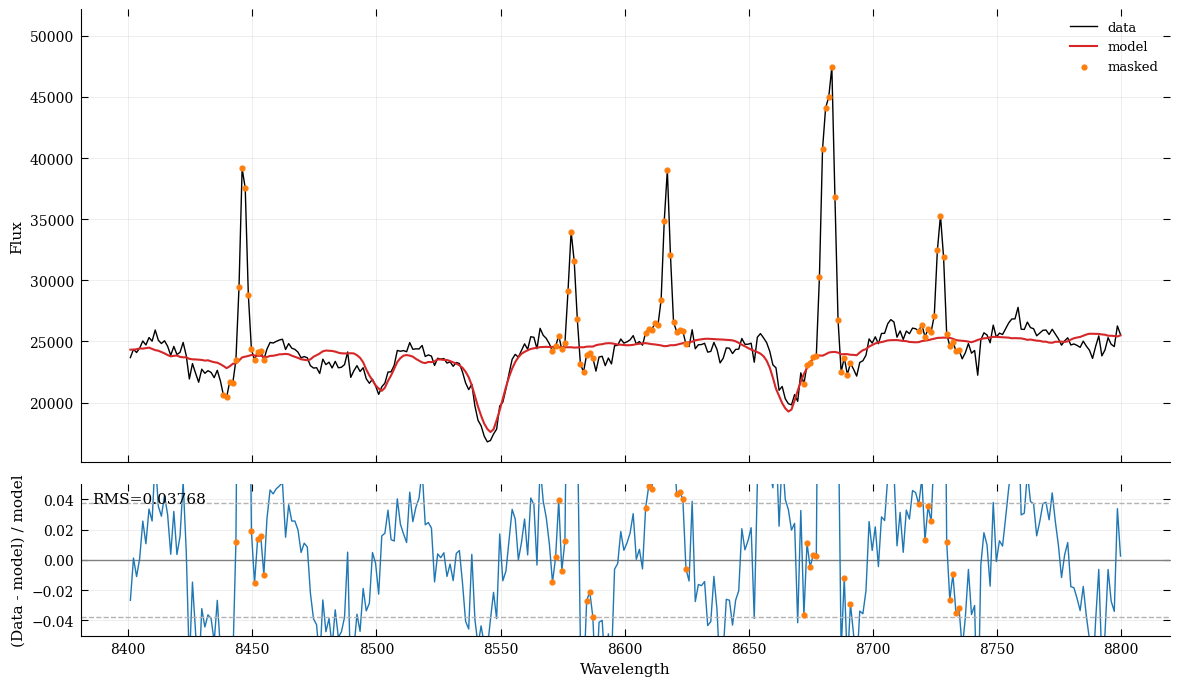

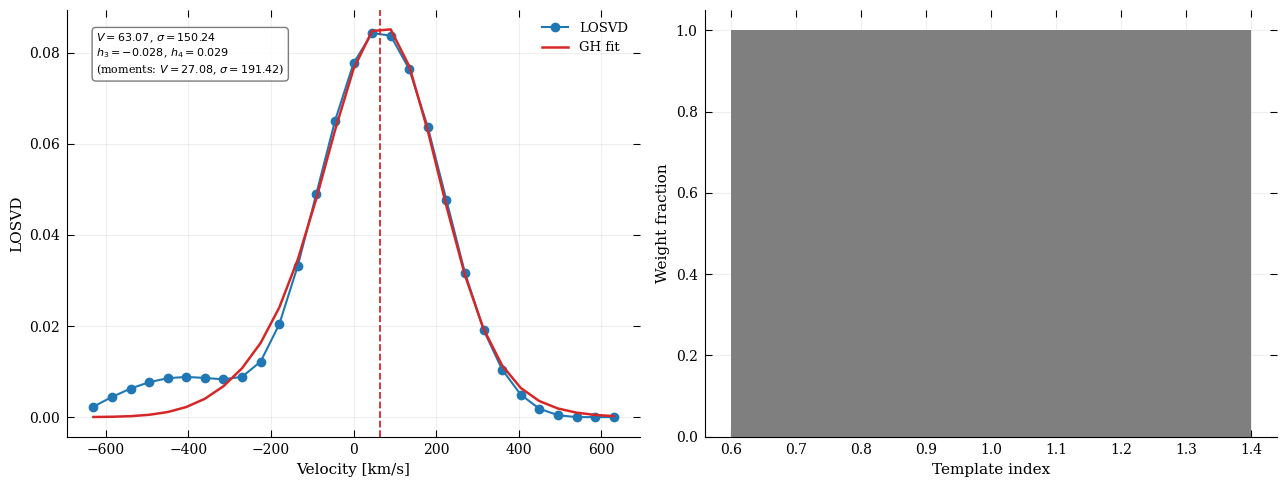

vherm=63.0687  sherm=150.2355  h3=-0.0281  h4=0.0285  success=True


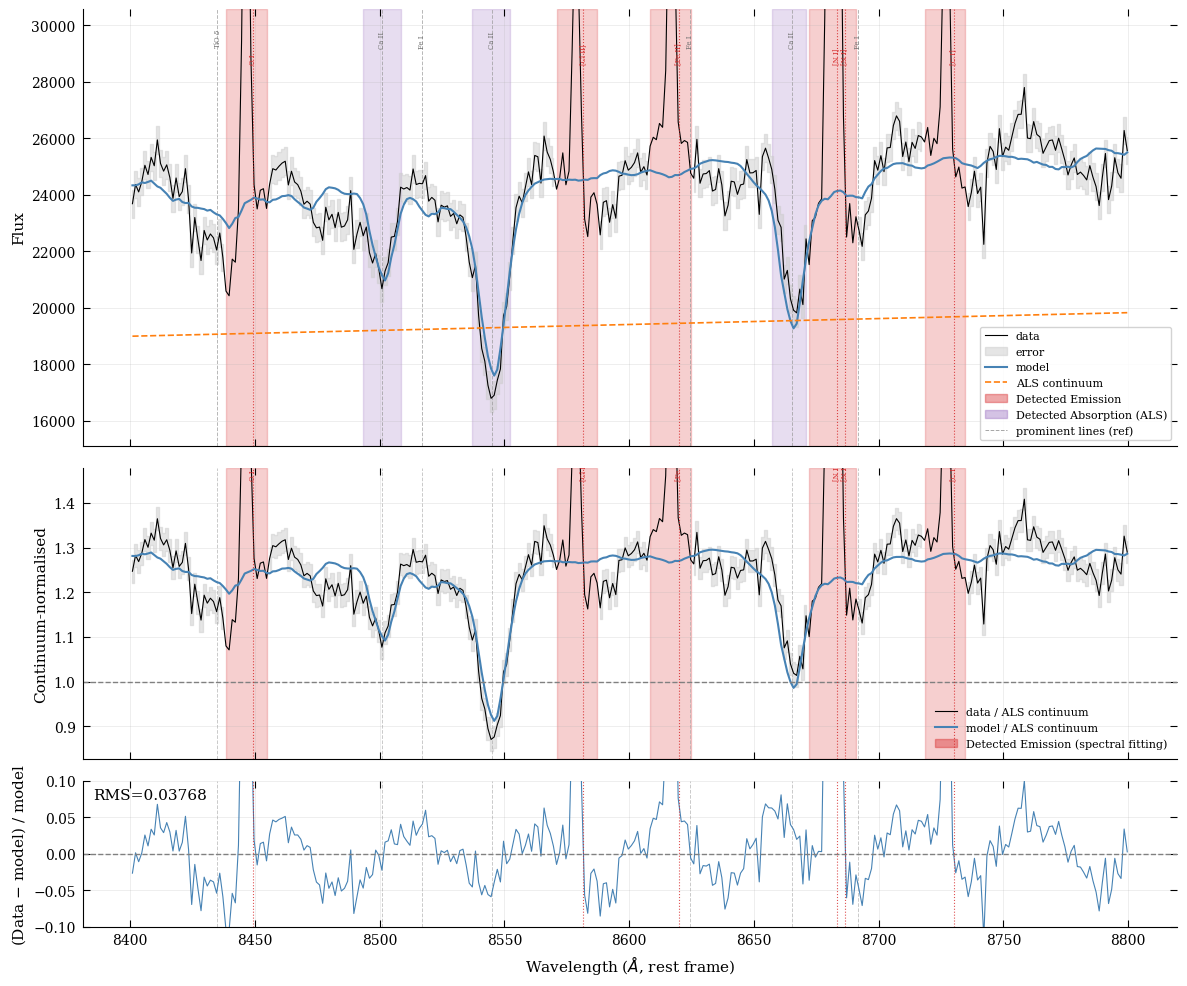

In [17]:
outputs_manual = {
    "gp": gp, "b": b, "w": w, "wfrac": wfrac, "tt": tt,
    "coff": coff, "coff2": coff2, "A": A, "continuum": cont_final,
}
fit_manual = {"state": st, "outputs": outputs_manual, "a_map": a_map, "chi2": chi2, "ngood": ngood}

plot_fit(fit_manual)
plot_losvd(fit_manual)
plot_als_continuum(fit_manual, cfg=cfg)

## 13. Cross-check: does this manual reproduction match `run_spectral_fit()`?

This is the key sanity check the whole notebook is building toward: every
step above was hand-called instead of going through the normal one-line API.
If the internal call sequence reproduced here is actually faithful to what
`run_spectral_fit()` does, refitting the *same* mock spectrum (same noise
draw) through the real black-box API should reproduce the same answer to
near machine precision (both use the deterministic L-BFGS-B optimizer from
the same starting point).

**Expect:** "MATCH" printed at the end. The raw `a_map` vector will *not*
be bit-identical between the two runs -- two independently-converged
L-BFGS-B fits from the same starting point can differ at the ~1e-4 level
purely from floating-point non-associativity in parallelized reductions
(numba/BLAS thread scheduling), even with nothing wrong -- so the match is
judged on physically meaningful quantities instead: chi2 agreeing to
~4 significant figures, and GH moments agreeing to well inside 1 km/s in
V/sigma and 0.01 in h3/h4. A real missing or reordered step in this
notebook's manual reproduction (or a genuine pipeline bug) would show up as
a much larger discrepancy than that -- km/s-to-tens-of-km/s in V/sigma, not
thousandths.

In [18]:
WORK_DIR_BLACKBOX = Path(tempfile.mkdtemp(prefix="kinextract_stepwise_blackbox_"))
paths_bb = write_mock_to_disk(mock, WORK_DIR_BLACKBOX, prefix="mock")
cfg_bb = dataclasses.replace(
    cfg, outdir=str(WORK_DIR_BLACKBOX), template_dir=str(WORK_DIR_BLACKBOX),
    template_list_file=str(paths_bb["tlist"]),
)

fit_blackbox = run_spectral_fit(cfg_bb, gal_file=str(paths_bb["spec"]), write_outputs=False)

max_abs_diff = np.max(np.abs(a_map - fit_blackbox["a_map"]))
print(f"manual a_map vs. run_spectral_fit a_map: max abs diff = {max_abs_diff:.3g}")
print(f"manual chi2={chi2:.4f}  run_spectral_fit chi2={fit_blackbox['chi2']:.4f}")

gh_bb = fit_losvd_gauss_hermite(fit_blackbox["state"].xl, fit_blackbox["outputs"]["b"], fit_h3h4=True)
print(f"manual GH moments:        V={gh['vherm']:.4f} sigma={gh['sherm']:.4f} h3={gh['h3']:.4f} h4={gh['h4']:.4f}")
print(f"run_spectral_fit moments: V={gh_bb['vherm']:.4f} sigma={gh_bb['sherm']:.4f} h3={gh_bb['h3']:.4f} h4={gh_bb['h4']:.4f}")

# Judge the match on physically meaningful quantities, not the raw a_map
# vector -- two independently-converged L-BFGS-B runs from the same start
# can differ at the ~1e-4 level from floating-point non-associativity alone
# (see markdown above), which would fail a naive np.allclose on a_map.
chi2_rel_diff = abs(chi2 - fit_blackbox["chi2"]) / max(abs(fit_blackbox["chi2"]), 1e-12)
v_diff, sigma_diff = abs(gh["vherm"] - gh_bb["vherm"]), abs(gh["sherm"] - gh_bb["sherm"])
h3_diff, h4_diff = abs(gh["h3"] - gh_bb["h3"]), abs(gh["h4"] - gh_bb["h4"])
is_match = (chi2_rel_diff < 1e-3) and (v_diff < 1.0) and (sigma_diff < 1.0) and (h3_diff < 0.01) and (h4_diff < 0.01)

if is_match:
    print("\nMATCH: manual step-by-step reproduction agrees with run_spectral_fit().")
else:
    print("\nMISMATCH: manual reproduction diverges from run_spectral_fit() -- "
          "investigate which step above differs from fitting.run_spectral_fit's actual call sequence.")

[     7.91s] ==== spectral fitting START | /var/folders/zp/_mj2qgk5107f3gf_2gnw4gnm0000gs/T/kinextract_stepwise_blackbox_dixhystx/mock.spec ====
[     7.91s] wavefit=[8400.0, 8800.0] z=0.0 sigl=140.0 xlam=100000.0
[     7.91s] fit_als_continuum=True prenorm=False
[     7.91s] START build FitState
[     7.91s] START read spectrum
[     7.91s] fit pixels=320 step=1.25
[     7.92s] END   read spectrum (0.00s)
[     7.92s] START apply masks
[     7.92s]   emission pre-mask O I 8446.36 Å  excess_S/N=32.0  cont_est=2.354e+04  npix=14
[     7.92s]   emission pre-mask [Cl II] 8578.70 Å  excess_S/N=19.1  cont_est=2.467e+04  npix=14
[     7.92s]   emission pre-mask [Fe II] 8616.95 Å  excess_S/N=29.1  cont_est=2.482e+04  npix=14
[     7.92s]   emission pre-mask [N I] 8680.28 Å  excess_S/N=49.5  cont_est=2.325e+04  npix=14
[     7.92s]   emission pre-mask [N I] 8683.40 Å  excess_S/N=49.3  cont_est=2.335e+04  npix=13
[     7.92s]   emission pre-mask [C I] 8727.13 Å  excess_S/N=20.2  cont_est=2.544e

## 14. (Optional, slower) Error estimation

Runs the Laplace-approximation covariance, a small residual bootstrap, and
the bias-corrected LOSVD estimate on the black-box fit from step 13.
`n_bootstrap=20` here is a quick smoke test, not a publication-quality error
bar -- raise it (50-200) for real error estimates, at the cost of runtime.

**Expect:** a summary dict with per-parameter formal uncertainties and a
couple of diagnostic plots; the printed Laplace and bootstrap sigma/V errors
should be broadly consistent with each other (same order of magnitude),
though the bootstrap is expected to be somewhat more conservative (larger)
since it captures continuum-refitting variance the Laplace approximation
does not.

In [ ]:
error_summary = estimate_losvd_errors(
    fit_blackbox, cfg_bb,
    run_laplace=True, run_bootstrap=True, run_bias=True,
    n_bootstrap=20, n_jobs=4, bootstrap_seed=42,
    plot=True, write_to_files=False,
)
print(error_summary)

[LOSVDErrors] Computing Hessian...
[LOSVDErrors] Using JAX gradient-backed Hessian FD (CPU)
[LOSVDErrors] Laplace covariance done in 0.4s. Hessian PD (free params): True. Pinned: 3/29 LOSVD bins, 1/1 template weights. Max projected |grad|: 1.2
[LOSVDErrors] Starting residual bootstrap (n=20, block=1, jobs=4)...
[LOSVDErrors] Using 4 worker threads
[    11.53s] Ca II mask shift: +3.210 Å  (als_mask_center_shift_A → 9.102 Å)
[    11.53s] Ca II mask shift: +2.841 Å  (als_mask_center_shift_A → 11.943 Å)
[    11.53s] Ca II mask shift: +3.197 Å  (als_mask_center_shift_A → 15.140 Å)
[    11.53s] Ca II mask shift: +2.647 Å  (als_mask_center_shift_A → 17.787 Å)
[    11.54s] ALS absorption-clean iter 1: sigma=3.072, rejected=0, base_pixels=222
[    11.54s] ALS absorption-clean iter 1: sigma=3.045, rejected=0, base_pixels=222
[    11.54s] ALS absorption-clean iter 1: sigma=2.864, rejected=0, base_pixels=222[    11.54s] ALS init: lam=1.000e+07 p=0.05 median=2.1e+04 base_pixels=222 line_mask_pixels

/Users/waterstk/Documents/Gultekin_Astrophysics/kinextract/src/kinextract/errors.py:2467: RuntimeWarning: Laplace covariance: the largest projected gradient component at the MAP solution is 1.2, above grad_warn_threshold=0.05. This suggests the MAP optimization did not fully converge, which can make the Hessian indefinite and the resulting error bars unreliable (some may be silently near-zero). Consider tightening map_ftol/map_gtol or enabling use_jax_objective before re-fitting.
  laplace = est.laplace_covariance()


[    11.58s] ALS absorption-clean iter 1: sigma=1.834, rejected=0, base_pixels=222
[    11.58s]   ALS update: lam=1.000e+07 p=0.05 delta=0.02623 base_pixels=222 line_mask_pixels=39
[    11.58s]   ALS continuum median fractional change = 0.02623
[    11.58s] ALS outer iteration 2/4
[    11.58s] START MAP optimize ALS outer 2
[    11.69s] END   MAP optimize ALS outer 1 (0.15s)
[    11.69s] END   MAP optimize ALS outer 1 (0.15s)
[    11.70s] ALS absorption-clean iter 1: sigma=2.05, rejected=0, base_pixels=222
[    11.70s] ALS absorption-clean iter 1: sigma=2.07, rejected=0, base_pixels=222[    11.70s]   ALS update: lam=1.000e+07 p=0.05 delta=0.03793 base_pixels=222 line_mask_pixels=39

[    11.70s]   ALS continuum median fractional change = 0.03793
[    11.70s]   ALS update: lam=1.000e+07 p=0.05 delta=0.03874 base_pixels=222 line_mask_pixels=39
[    11.70s] ALS outer iteration 2/4
[    11.70s] START MAP optimize ALS outer 2
[    11.70s]   ALS continuum median fractional change = 0.03874
[

## 15. (Optional) The sigma-clipping "clean" path

This configuration used `cfg.clean=False`, so `run_iterative_clean_map` and
`build_clean_protect_mask` were never exercised above. For completeness,
this section builds a *separate* `FitState` (so it can't contaminate any of
the results above) with `clean=True` and runs that path directly:
`build_clean_protect_mask` marks pixels (e.g. a window around the Ca II
triplet) that must never be sigma-clipped even if poorly fit, and
`run_iterative_clean_map` alternates fitting with clipping outlier pixels
until convergence.

**Expect:** since this mock has no cosmic rays or bad columns injected, very
few (ideally zero, or only a handful of noise-driven outliers) pixels
should end up rejected -- ordinary emission-masked pixels are already
excluded before cleaning even starts, so cleaning should not be needed for
this particular data set. This is a demonstration of the mechanism, not a
verification that the current mock triggers it.

In [ ]:
cfg_clean = dataclasses.replace(cfg, clean=True)
st_clean_demo, _ = make_fit_state(cfg_clean, gal_file=str(paths["spec"]))
a0_clean_demo, xlb_c, xub_c = build_initial_guess_nonparam(st_clean_demo, cfg_clean.coff, cfg_clean.coff2)
bounds_clean_demo = list(zip(xlb_c, xub_c))

protect_mask = build_clean_protect_mask(st_clean_demo, cfg_clean)
print(f"protect_mask: {int(protect_mask.sum())} / {st_clean_demo.npix} pixels protected from clipping")

res_clean, good_mask = run_iterative_clean_map(
    st_clean_demo, a0_clean_demo, bounds_clean_demo,
    cfg_clean.map_maxiter, cfg_clean.map_ftol, cfg_clean.map_maxfun, cfg_clean.print_every,
    cfg_clean.clean_sigma, cfg_clean.clean_maxiter, cfg_clean.clean_minpix,
    protect_mask, cfg_clean.clean_protect_absorption_only, cfg_clean.clean_bloom_pixels,
    **map_kwargs,
)
print(f"clean run: {int((~good_mask).sum())} pixels rejected out of {st_clean_demo.npix}")

[    17.00s] START read spectrum
[    17.00s] fit pixels=320 step=1.25
[    17.00s] END   read spectrum (0.00s)
[    17.00s] START apply masks
[    17.00s]   emission pre-mask O I 8446.36 Å  excess_S/N=33.6  cont_est=2.351e+04  npix=14
[    17.00s]   emission pre-mask [Cl II] 8578.70 Å  excess_S/N=21.1  cont_est=2.438e+04  npix=14
[    17.00s]   emission pre-mask [Fe II] 8616.95 Å  excess_S/N=25.9  cont_est=2.5e+04  npix=14
[    17.00s]   emission pre-mask [N I] 8680.28 Å  excess_S/N=52.2  cont_est=2.389e+04  npix=14
[    17.00s]   emission pre-mask [N I] 8683.40 Å  excess_S/N=52.2  cont_est=2.389e+04  npix=13
[    17.00s]   emission pre-mask [C I] 8727.13 Å  excess_S/N=21.8  cont_est=2.513e+04  npix=14
[    17.01s] Emission line pre-mask: 72 pixels set to gerr=BIG
[    17.01s] Segment emission mask [8674.1–8799.6 Å]: 1 upward-outlier pixels (>3σ above rolling median)
[    17.01s] Segment emission pre-mask: 1 additional pixels
[    17.01s] END   apply masks (0.01s)
[    17.01s] START r

## 16. Summary report card

A single place to eyeball everything this notebook checked, all at once.

In [ ]:
print(f"{'quantity':16s}{'truth':>10s}{'manual':>12s}{'blackbox':>12s}")
for name, truth, manual_val, bb_val in (
    ("V [km/s]", V_TRUE, gh["vherm"], gh_bb["vherm"]),
    ("sigma [km/s]", SIGMA_TRUE, gh["sherm"], gh_bb["sherm"]),
    ("h3", H3_TRUE, gh["h3"], gh_bb["h3"]),
    ("h4", H4_TRUE, gh["h4"], gh_bb["h4"]),
):
    print(f"{name:16s}{truth:10.4f}{manual_val:12.4f}{bb_val:12.4f}")

print(f"\nchi2_red (manual)    = {chi2_red:.4f}")
print(f"chi2_red (blackbox)  = {fit_blackbox['chi2'] / max(fit_blackbox['ngood'] - 1, 1):.4f}")
print(f"selected xlam        = {st.xlam:.0f}")
print(f"manual/blackbox cross-check: {'MATCH' if is_match else 'MISMATCH'}  "
      f"(chi2 rel diff={chi2_rel_diff:.2e}, V diff={v_diff:.3f}, sigma diff={sigma_diff:.3f})")
print(f"clean-path pixels rejected (separate demo state) = {int((~good_mask).sum())} / {st_clean_demo.npix}")

quantity             truth      manual    blackbox
V [km/s]           80.0000     73.2987     73.2956
sigma [km/s]      140.0000    141.9375    141.9169
h3                  0.0500      0.0393      0.0393
h4                  0.0500      0.0126      0.0126

chi2_red (manual)    = 1.0350
chi2_red (blackbox)  = 1.0350
selected xlam        = 100000
manual/blackbox cross-check: MATCH  (chi2 rel diff=8.83e-06, V diff=0.003, sigma diff=0.021)
clean-path pixels rejected (separate demo state) = 74 / 320
